# Student Placement Prediction

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Loading Dataset

In [2]:
import pandas as pd
df1 = pd.read_csv("/content/drive/MyDrive/Training/placementdata.csv")

In [3]:
df1

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,7.5,1,1,2,72,3.9,Yes,No,85,66,NotPlaced
9996,9997,7.4,0,1,0,90,4.8,No,No,84,67,Placed
9997,9998,8.4,1,3,0,70,4.8,Yes,Yes,79,81,Placed
9998,9999,8.9,0,3,2,87,4.8,Yes,Yes,71,85,Placed


Import Libraries

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data Exploration

In [5]:
df1.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [6]:
df1.tail()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
9995,9996,7.5,1,1,2,72,3.9,Yes,No,85,66,NotPlaced
9996,9997,7.4,0,1,0,90,4.8,No,No,84,67,Placed
9997,9998,8.4,1,3,0,70,4.8,Yes,Yes,79,81,Placed
9998,9999,8.9,0,3,2,87,4.8,Yes,Yes,71,85,Placed
9999,10000,8.4,0,1,1,66,3.8,No,No,62,66,NotPlaced


In [7]:
df1.shape

(10000, 12)

In [8]:
df1.columns

Index(['StudentID', 'CGPA', 'Internships', 'Projects',
       'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating',
       'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks',
       'HSC_Marks', 'PlacementStatus'],
      dtype='object')

In [9]:
df1.describe()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,7.698010,1.049200,2.026600,1.013200,79.449900,4.323960,69.159400,74.501500
std,2886.89568,0.640131,0.665901,0.867968,0.904272,8.159997,0.411622,10.430459,8.919527
min,1.00000,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,55.000000,57.000000
25%,2500.75000,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,59.000000,67.000000
50%,5000.50000,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,70.000000,73.000000
75%,7500.25000,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,78.000000,83.000000
max,10000.00000,9.100000,2.000000,3.000000,3.000000,90.000000,4.800000,90.000000,88.000000


In [10]:
df1.isnull().sum()

,0
StudentID,0
CGPA,0
Internships,0
Projects,0
Workshops/Certifications,0
AptitudeTestScore,0
SoftSkillsRating,0
ExtracurricularActivities,0
PlacementTraining,0
SSC_Marks,0


In [11]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  object 
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB


In [12]:
df1.duplicated().sum()

np.int64(0)

In [13]:
df1.nunique()

,0
StudentID,10000
CGPA,27
Internships,3
Projects,4
Workshops/Certifications,4
AptitudeTestScore,31
SoftSkillsRating,19
ExtracurricularActivities,2
PlacementTraining,2
SSC_Marks,36


In [14]:
df1.dtypes

,0
StudentID,int64
CGPA,float64
Internships,int64
Projects,int64
Workshops/Certifications,int64
AptitudeTestScore,int64
SoftSkillsRating,float64
ExtracurricularActivities,object
PlacementTraining,object
SSC_Marks,int64


In [15]:
df1['PlacementStatus'].value_counts()

,count
PlacementStatus,
NotPlaced,5803
Placed,4197


Data Visualisation

/tmp/ipykernel_792/4093973761.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="PlacementStatus",data=df1,palette=["#4CAF50","#F44336"],edgecolor="black")


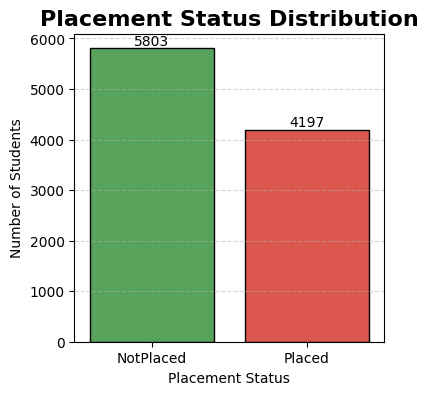

In [16]:
#Placement Status Distribution
plt.figure(figsize=(4, 4))
ax = sns.countplot(x="PlacementStatus",data=df1,palette=["#4CAF50","#F44336"],edgecolor="black")
plt.title("Placement Status Distribution",fontsize=16,fontweight="bold")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.grid(axis="y",linestyle="--",alpha=0.5)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

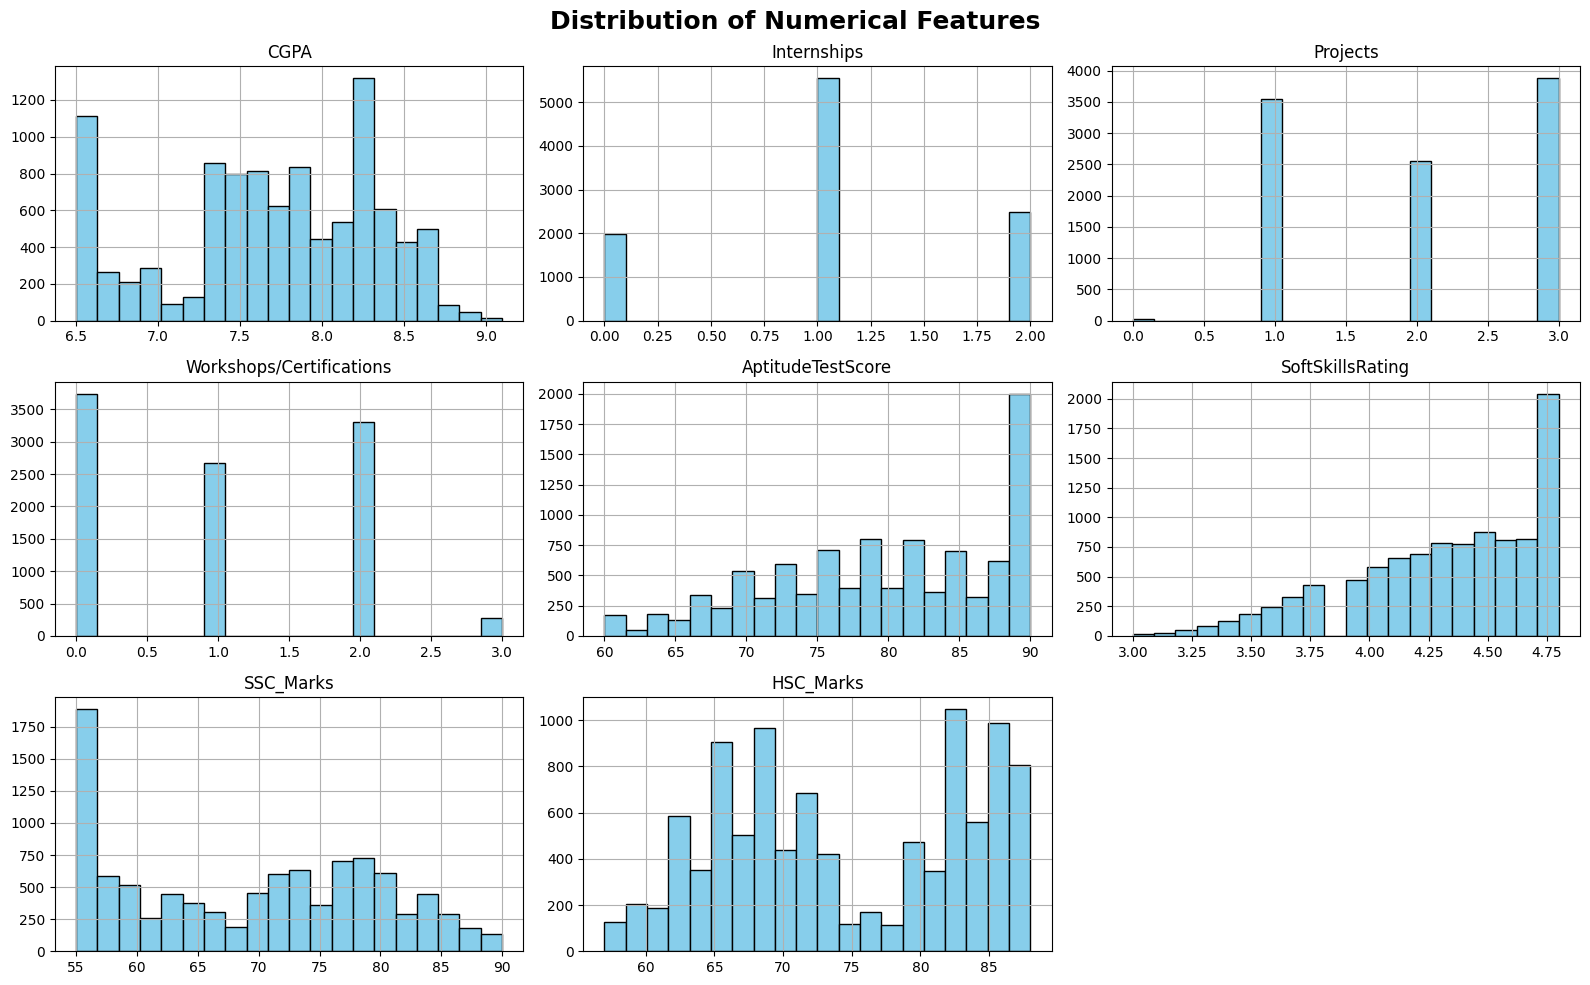

In [17]:
#Distribution of Numerical Features
numerical_cols = ["CGPA","Internships","Projects","Workshops/Certifications","AptitudeTestScore","SoftSkillsRating","SSC_Marks","HSC_Marks"]
df1[numerical_cols].hist(figsize=(16,10),bins=20,edgecolor="black",color="skyblue")
plt.suptitle("Distribution of Numerical Features",fontsize=18,fontweight="bold")
plt.tight_layout()
plt.show()

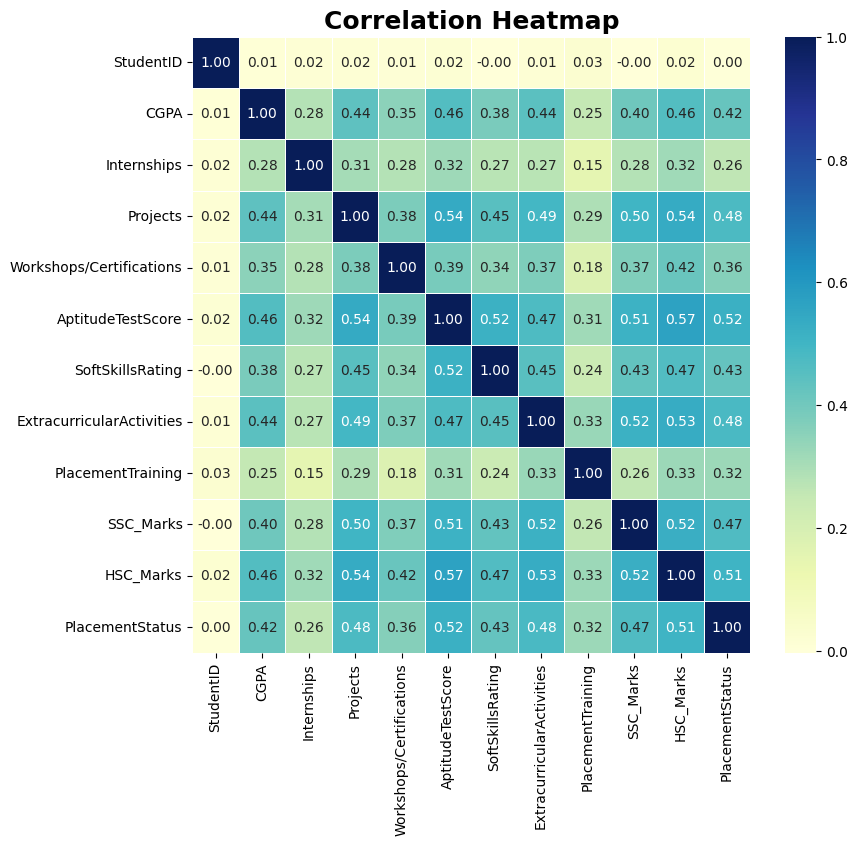

In [18]:
#Correlation Heatmap
df1_heatmap = df1.copy()
df1_heatmap["ExtracurricularActivities"] = df1_heatmap["ExtracurricularActivities"].map({"Yes":1,"No":0})
df1_heatmap["PlacementTraining"] = df1_heatmap["PlacementTraining"].map({"Yes":1,"No":0})
df1_heatmap["PlacementStatus"] = df1_heatmap["PlacementStatus"].map({"Placed":1,"NotPlaced":0})
plt.figure(figsize=(9,8))
sns.heatmap(df1_heatmap.corr(),annot=True,cmap="YlGnBu",fmt=".2f",linewidths=0.5)
plt.title("Correlation Heatmap",fontsize=18,fontweight="bold")
plt.show()

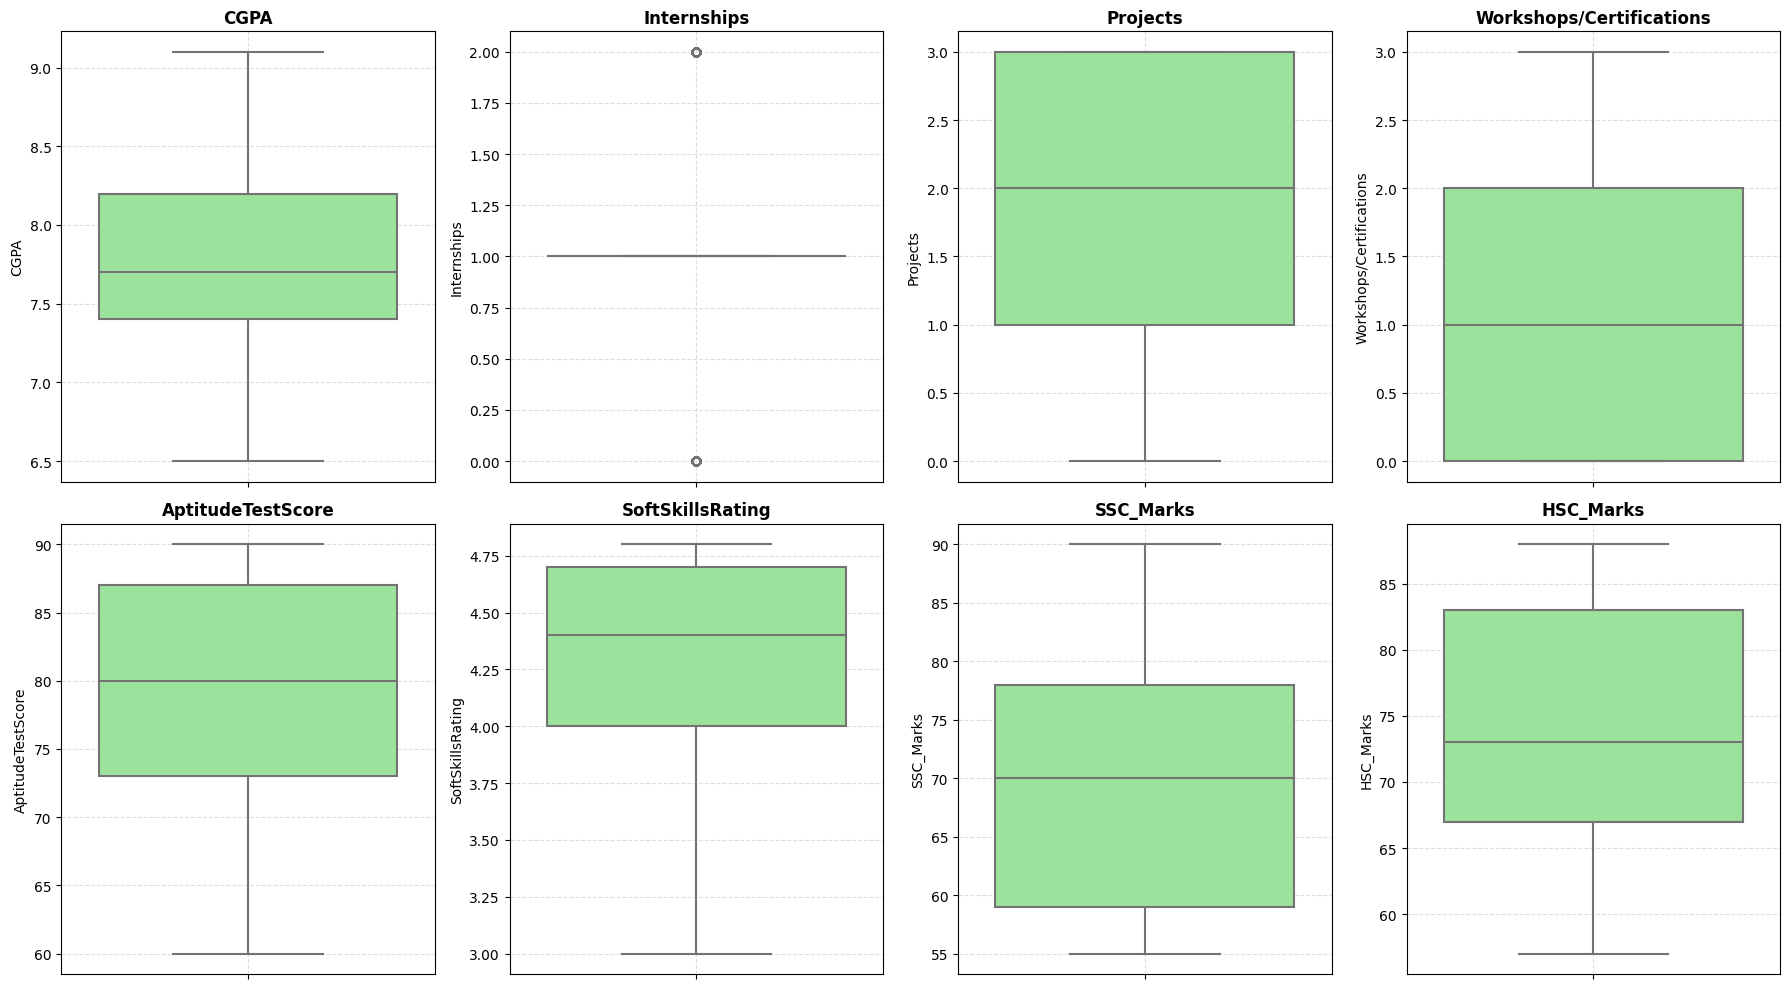

In [19]:
#Boxplots (Outlier Detection)
fig, axes = plt.subplots(2,4,figsize=(18,10))
for ax,col in zip(axes.flatten(),numerical_cols):
    sns.boxplot(y=df1[col],color="lightgreen",linewidth=1.5,ax=ax)
    ax.set_title(col,fontweight="bold")
    ax.grid(ls="--",alpha=0.4)
plt.tight_layout()
plt.show()

/tmp/ipykernel_792/4068747038.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="PlacementStatus",y="CGPA",data=avg_cgpa,palette=["skyblue","pink"],edgecolor="black")


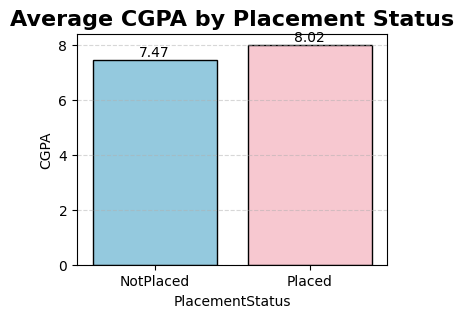

In [20]:
#Average CGPA by Placement Status
avg_cgpa = df1.groupby("PlacementStatus")["CGPA"].mean().reset_index()
plt.figure(figsize=(4, 3))
ax = sns.barplot(x="PlacementStatus",y="CGPA",data=avg_cgpa,palette=["skyblue","pink"],edgecolor="black")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")
plt.title("Average CGPA by Placement Status",fontsize=16,fontweight="bold")
plt.grid(axis="y",linestyle="--",alpha=0.5)
plt.show()

/tmp/ipykernel_792/417858244.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="PlacementStatus",y="CGPA",data=df1,palette=["skyblue","pink"])


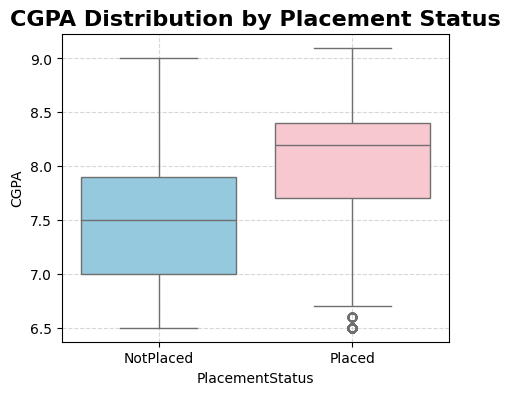

In [21]:
# comapres CGPA distributions of placed and not placed students
plt.figure(figsize=(5, 4))
sns.boxplot(x="PlacementStatus",y="CGPA",data=df1,palette=["skyblue","pink"])
plt.title("CGPA Distribution by Placement Status",fontsize=16,fontweight="bold")
plt.grid(ls="--",alpha=0.5)
plt.show()

Data Preprocessing

In [22]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [23]:
#encode categorical columns
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df1['ExtracurricularActivities']=le.fit_transform(df1['ExtracurricularActivities'])
df1['PlacementTraining']=le.fit_transform(df1['PlacementTraining'])
df1['PlacementStatus']=le.fit_transform(df1['PlacementStatus'])

df1

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,0,0,61,79,0
1,2,8.9,0,3,2,90,4.0,1,1,78,82,1
2,3,7.3,1,2,2,82,4.8,1,0,79,80,0
3,4,7.5,1,1,2,85,4.4,1,1,81,80,1
4,5,8.3,1,2,2,86,4.5,1,1,74,88,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,7.5,1,1,2,72,3.9,1,0,85,66,0
9996,9997,7.4,0,1,0,90,4.8,0,0,84,67,1
9997,9998,8.4,1,3,0,70,4.8,1,1,79,81,1
9998,9999,8.9,0,3,2,87,4.8,1,1,71,85,1


In [24]:
X=df1.drop(columns=['PlacementStatus', 'StudentID'],axis=1)
y=df1['PlacementStatus']

In [25]:
X

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks
0,7.5,1,1,1,65,4.4,0,0,61,79
1,8.9,0,3,2,90,4.0,1,1,78,82
2,7.3,1,2,2,82,4.8,1,0,79,80
3,7.5,1,1,2,85,4.4,1,1,81,80
4,8.3,1,2,2,86,4.5,1,1,74,88
...,...,...,...,...,...,...,...,...,...,...
9995,7.5,1,1,2,72,3.9,1,0,85,66
9996,7.4,0,1,0,90,4.8,0,0,84,67
9997,8.4,1,3,0,70,4.8,1,1,79,81
9998,8.9,0,3,2,87,4.8,1,1,71,85


In [26]:
y

,PlacementStatus
0,0
1,1
2,0
3,1
4,1
...,...
9995,0
9996,1
9997,1
9998,1


In [27]:
# Splittion of Training and Testing Data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [28]:
X_train

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks
4901,8.4,2,3,2,86,4.8,1,1,74,81
4375,7.6,1,2,0,73,3.8,0,1,76,64
6698,8.2,2,3,2,90,4.7,1,1,78,84
9805,8.2,1,3,1,78,4.0,0,1,58,85
1101,7.5,0,2,0,78,4.4,0,1,62,65
...,...,...,...,...,...,...,...,...,...,...
5734,6.5,1,1,0,72,4.8,0,0,68,70
5191,7.4,1,1,0,67,4.1,0,1,60,73
5390,7.4,1,1,0,71,4.3,1,1,55,66
860,8.0,1,1,0,84,3.9,1,0,55,66


In [29]:
y_train

,PlacementStatus
4901,1
4375,0
6698,1
9805,1
1101,0
...,...
5734,0
5191,0
5390,0
860,0


Feature Scaling

In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [33]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

Logistic Regression

In [34]:
model1 = LogisticRegression()
model1.fit(X_train,y_train)
y_pred1 = model1.predict(X_test)

In [35]:
print ("Logistic Accuracay:")
accuracy_score(y_test,y_pred1)

Logistic Accuracay:


0.792

In [36]:
print(confusion_matrix(y_test,y_pred1))
print(classification_report(y_test,y_pred1))

[[1183  275]
 [ 245  797]]
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      1458
           1       0.74      0.76      0.75      1042

    accuracy                           0.79      2500
   macro avg       0.79      0.79      0.79      2500
weighted avg       0.79      0.79      0.79      2500



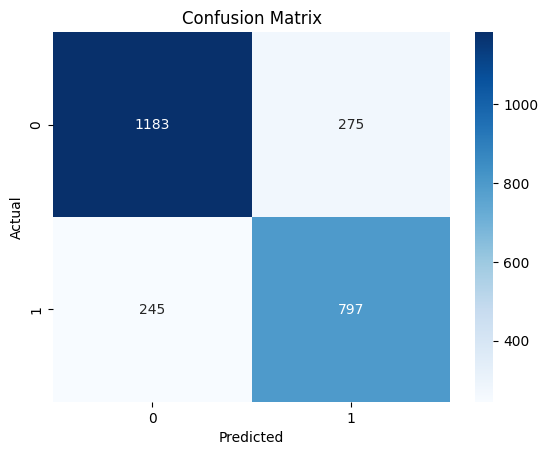

In [37]:
cm = confusion_matrix(y_test,y_pred1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

KNN

In [38]:
model2 = KNeighborsClassifier()
model2.fit(X_train,y_train)
y_pred2 = model2.predict(X_test)

In [39]:
print ("KNN Accuracy:")
accuracy_score(y_test,y_pred2)

KNN Accuracy:


0.7684

In [40]:
print(confusion_matrix(y_test,y_pred2))
print(classification_report(y_test,y_pred2))

[[1177  281]
 [ 298  744]]
              precision    recall  f1-score   support

           0       0.80      0.81      0.80      1458
           1       0.73      0.71      0.72      1042

    accuracy                           0.77      2500
   macro avg       0.76      0.76      0.76      2500
weighted avg       0.77      0.77      0.77      2500



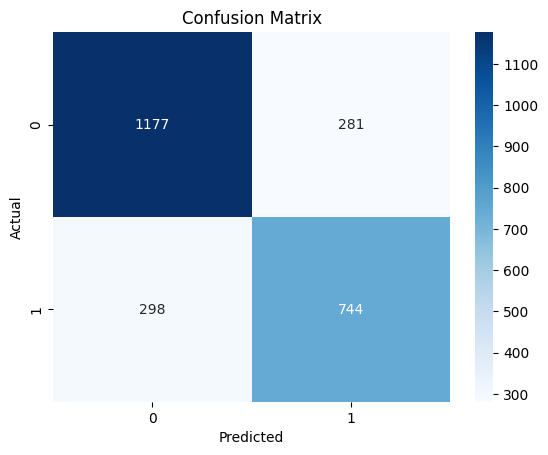

In [41]:
cm = confusion_matrix(y_test,y_pred2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Decision Tree

In [42]:
model3 = DecisionTreeClassifier()
model3.fit(X_train,y_train)
y_pred3 = model3.predict(X_test)

In [43]:
print ("Decision Tree Accuracy:")
accuracy_score(y_test,y_pred3)

Decision Tree Accuracy:


0.7212

In [44]:
print(confusion_matrix(y_test,y_pred3))
print(classification_report(y_test,y_pred3))

[[1103  355]
 [ 342  700]]
              precision    recall  f1-score   support

           0       0.76      0.76      0.76      1458
           1       0.66      0.67      0.67      1042

    accuracy                           0.72      2500
   macro avg       0.71      0.71      0.71      2500
weighted avg       0.72      0.72      0.72      2500



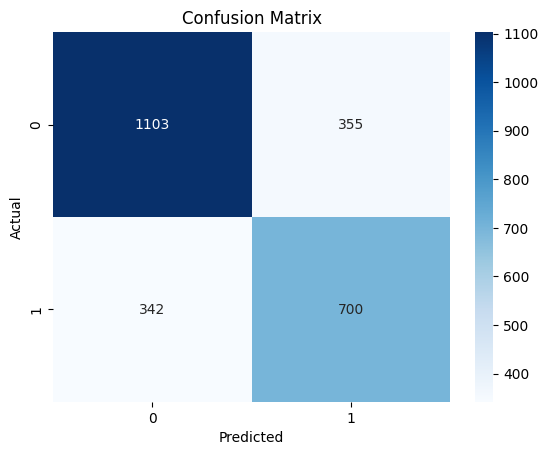

In [45]:
cm = confusion_matrix(y_test,y_pred3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Random Forest

In [46]:
model4 = RandomForestClassifier()
model4.fit(X_train,y_train)
y_pred4 = model4.predict(X_test)

In [47]:
print ("Random Forest Accuracy:")
accuracy_score(y_test,y_pred4)

Random Forest Accuracy:


0.7792

In [48]:
print(confusion_matrix(y_test,y_pred4))
print(classification_report(y_test,y_pred4))

[[1203  255]
 [ 297  745]]
              precision    recall  f1-score   support

           0       0.80      0.83      0.81      1458
           1       0.74      0.71      0.73      1042

    accuracy                           0.78      2500
   macro avg       0.77      0.77      0.77      2500
weighted avg       0.78      0.78      0.78      2500



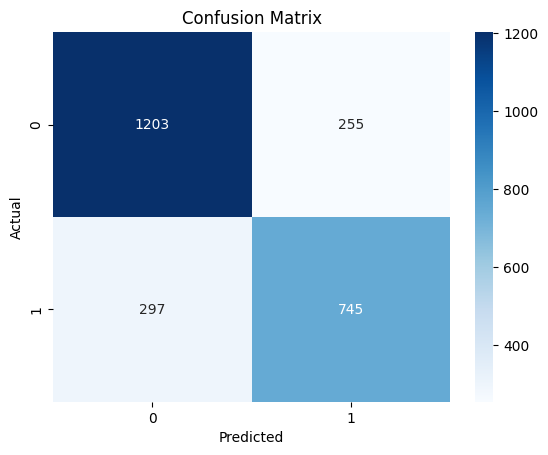

In [49]:
cm = confusion_matrix(y_test,y_pred4)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Comparison of different models Accuracy

In [50]:
final_result = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred1),
        accuracy_score(y_test,y_pred2),
        accuracy_score(y_test,y_pred3),
        accuracy_score(y_test,y_pred4)
    ]
})
print(final_result)

                 Model  Accuracy
0  Logistic Regression    0.7920
1                  KNN    0.7684
2        Decision Tree    0.7212
3        Random Forest    0.7792


In [51]:
best = final_result.loc[final_result['Accuracy'].idxmax()]
print("Best Model:", best["Model"])
print("Accuracy:", best["Accuracy"])

Best Model: Logistic Regression
Accuracy: 0.792


Classification Report

Text(0.5, 1.0, 'Model Accuracy Comparison')

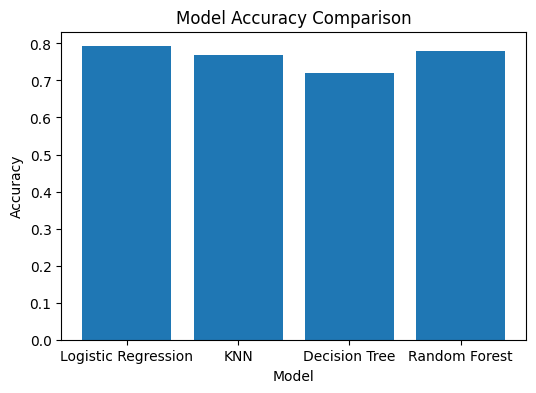

In [52]:
plt.figure(figsize=(6,4))
plt.bar(final_result["Model"],final_result["Accuracy"])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

# Loan Approval Prediction

Loading Dataset

In [53]:
import pandas as pd
df2 = pd.read_csv("/content/drive/MyDrive/Training/LoanApprovalPridiction.csv")

In [54]:
df2

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


Data Exploration

In [55]:
df2.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [56]:
df2.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [57]:
df2.shape

(614, 13)

In [58]:
df2.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [59]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [60]:
df2.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [61]:
df2.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [62]:
df2.duplicated().sum()

np.int64(0)

In [63]:
df2.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [64]:
df2.nunique()

,0
Loan_ID,614
Gender,2
Married,2
Dependents,4
Education,2
Self_Employed,2
ApplicantIncome,505
CoapplicantIncome,287
LoanAmount,203
Loan_Amount_Term,10


In [65]:
df2["Loan_Status"].value_counts()

,count
Loan_Status,
Y,422
N,192


EDA

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

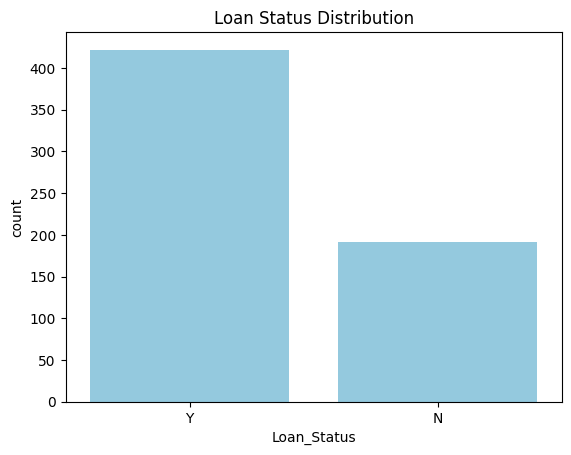

In [67]:
#Loan Status Distribution
sns.countplot(x="Loan_Status", data=df2, color = 'skyblue')
plt.title("Loan Status Distribution")
plt.show()

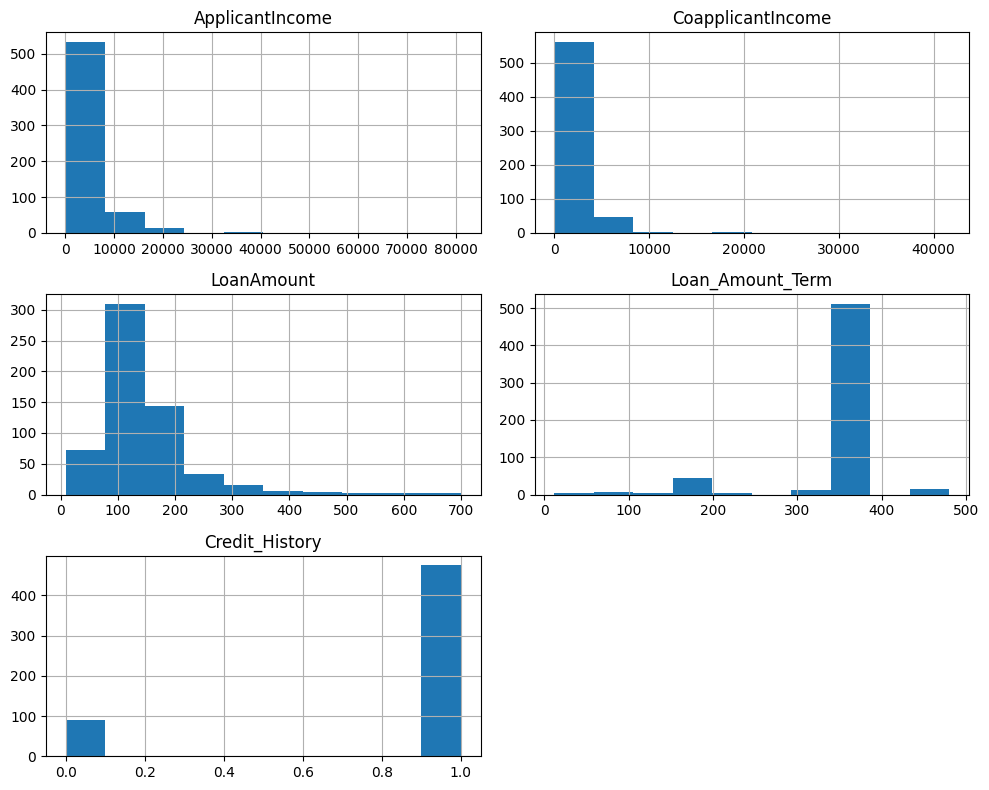

In [68]:
#Histograms
df2.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

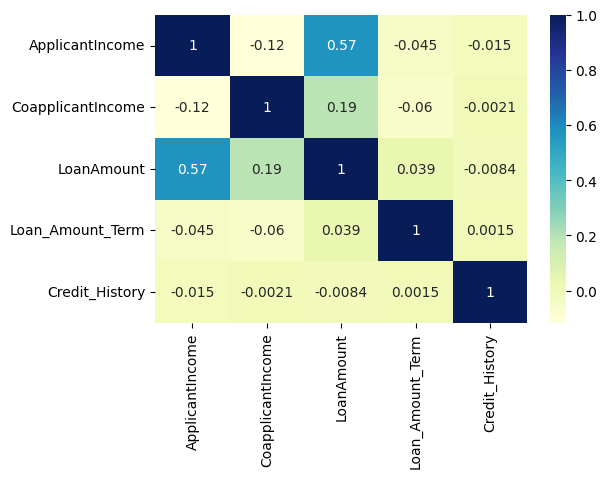

In [69]:
plt.figure(figsize=(6,4))
sns.heatmap(df2.corr(numeric_only=True), annot=True, cmap="YlGnBu")
plt.show()

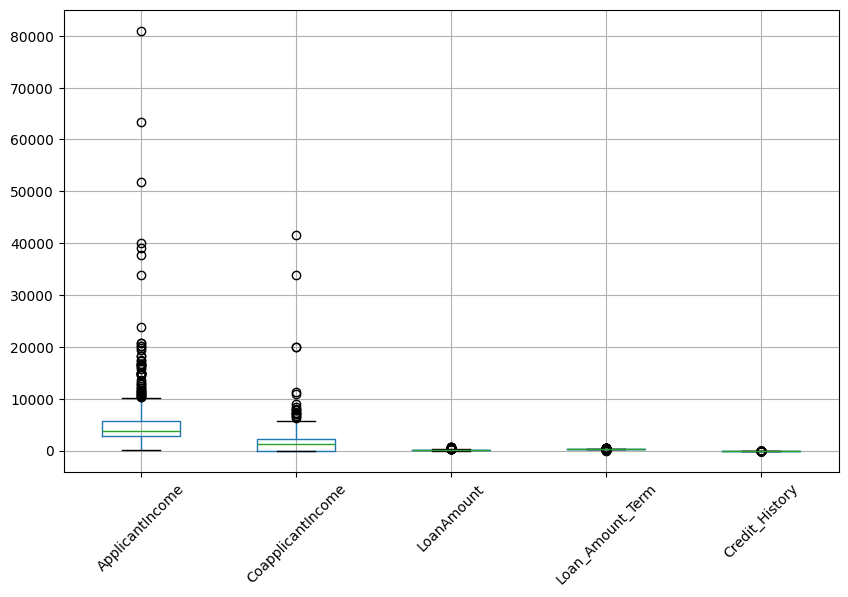

In [70]:
#boxplots
df2.boxplot(figsize=(10,6))
plt.xticks(rotation=45)
plt.show()

Data Preprocessing

In [71]:
#dropping loan id column
df2.drop("Loan_ID",axis=1,inplace=True)
df2

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [72]:
df2['Gender'].fillna(df2['Gender'].mode()[0], inplace=True)
df2['Married'].fillna(df2['Married'].mode()[0], inplace=True)
df2['Dependents'].fillna(df2['Dependents'].mode()[0], inplace=True)
df2['Self_Employed'].fillna(df2['Self_Employed'].mode()[0], inplace=True)
df2['Credit_History'].fillna(df2['Credit_History'].mode()[0], inplace=True)

/tmp/ipykernel_792/1630594867.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['Gender'].fillna(df2['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_792/1630594867.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [73]:
#fill numerical missing values
df2["LoanAmount"]=df2["LoanAmount"].fillna(df2["LoanAmount"].mean())
df2["Loan_Amount_Term"]=df2["Loan_Amount_Term"].fillna(df2["Loan_Amount_Term"].mean())

In [74]:
from sklearn.preprocessing import LabelEncoder

In [76]:
le = LabelEncoder()

for column in df2.columns:
    if df2[column].dtype == 'object':
        df2[column] = le.fit_transform(df2[column])
df2

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,146.412162,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,2900,0.0,71.000000,360.0,1.0,0,1
610,1,1,3,0,0,4106,0.0,40.000000,180.0,1.0,0,1
611,1,1,1,0,0,8072,240.0,253.000000,360.0,1.0,2,1
612,1,1,2,0,0,7583,0.0,187.000000,360.0,1.0,2,1


In [77]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    int64  
 1   Married            614 non-null    int64  
 2   Dependents         614 non-null    int64  
 3   Education          614 non-null    int64  
 4   Self_Employed      614 non-null    int64  
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    int64  
 11  Loan_Status        614 non-null    int64  
dtypes: float64(4), int64(8)
memory usage: 57.7 KB


Splitting the dataset into training and testing

In [78]:
X=df2.drop("Loan_Status",axis=1)
y=df2["Loan_Status"]

In [79]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [80]:
X_train

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
92,1,1,2,1,0,3273,1820.0,81.000000,360.0,1.0,2
304,1,0,0,0,0,4000,2500.0,140.000000,360.0,1.0,0
68,1,1,3,1,1,7100,0.0,125.000000,60.0,1.0,2
15,1,0,0,0,0,4950,0.0,125.000000,360.0,1.0,2
211,1,1,3,0,0,3430,1250.0,128.000000,360.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...
71,1,1,2,1,1,1875,1875.0,97.000000,360.0,1.0,1
106,1,1,2,0,0,11417,1126.0,225.000000,360.0,1.0,2
270,0,0,0,0,0,3237,0.0,30.000000,360.0,1.0,2
435,0,1,0,0,0,10047,0.0,146.412162,240.0,1.0,1


In [81]:
y_train

,Loan_Status
92,1
304,1
68,1
15,1
211,0
...,...
71,1
106,1
270,1
435,1


Feature Scaling

In [82]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Logistic Regression

In [83]:
from sklearn.linear_model import LogisticRegression

In [84]:
lr=LogisticRegression()
lr.fit(X_train,y_train)

LogisticRegression()

In [85]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [86]:
y_pred1=lr.predict(X_test)
print(accuracy_score(y_test,y_pred1))

0.7727272727272727


In [87]:
print(confusion_matrix(y_test,y_pred1))
print(classification_report(y_test,y_pred1))

[[21 33]
 [ 2 98]]
              precision    recall  f1-score   support

           0       0.91      0.39      0.55        54
           1       0.75      0.98      0.85       100

    accuracy                           0.77       154
   macro avg       0.83      0.68      0.70       154
weighted avg       0.81      0.77      0.74       154



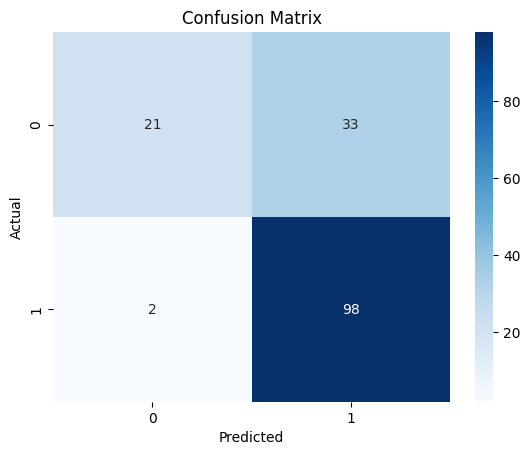

In [88]:
cm = confusion_matrix(y_test,y_pred1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

KNN

In [89]:
from sklearn.neighbors import KNeighborsClassifier

In [90]:
knn=KNeighborsClassifier()
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [91]:
y_pred2=knn.predict(X_test)
print(accuracy_score(y_test,y_pred2))

0.7597402597402597


In [92]:
print(confusion_matrix(y_test,y_pred2))
print(classification_report(y_test,y_pred2))

[[23 31]
 [ 6 94]]
              precision    recall  f1-score   support

           0       0.79      0.43      0.55        54
           1       0.75      0.94      0.84       100

    accuracy                           0.76       154
   macro avg       0.77      0.68      0.69       154
weighted avg       0.77      0.76      0.74       154



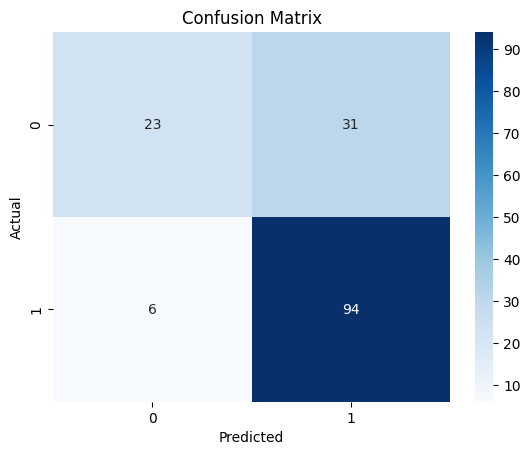

In [93]:
cm = confusion_matrix(y_test,y_pred2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Decision Tree

In [94]:
from sklearn.tree import DecisionTreeClassifier

In [95]:
dt=DecisionTreeClassifier()
dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [96]:
y_pred3=dt.predict(X_test)
print(accuracy_score(y_test,y_pred3))

0.6948051948051948


In [97]:
print(confusion_matrix(y_test,y_pred3))
print(classification_report(y_test,y_pred3))

[[25 29]
 [18 82]]
              precision    recall  f1-score   support

           0       0.58      0.46      0.52        54
           1       0.74      0.82      0.78       100

    accuracy                           0.69       154
   macro avg       0.66      0.64      0.65       154
weighted avg       0.68      0.69      0.69       154



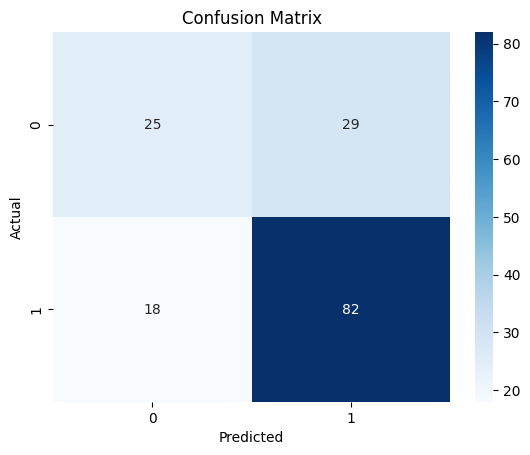

In [98]:
cm = confusion_matrix(y_test,y_pred3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Random Forest

In [99]:
from sklearn.ensemble import RandomForestClassifier

In [100]:
rf=RandomForestClassifier()
rf.fit(X_train,y_train)

RandomForestClassifier()

In [101]:
y_pred4=rf.predict(X_test)
print(accuracy_score(y_test,y_pred4))

0.7792207792207793


In [102]:
print(confusion_matrix(y_test,y_pred4))
print(classification_report(y_test,y_pred4))

[[25 29]
 [ 5 95]]
              precision    recall  f1-score   support

           0       0.83      0.46      0.60        54
           1       0.77      0.95      0.85       100

    accuracy                           0.78       154
   macro avg       0.80      0.71      0.72       154
weighted avg       0.79      0.78      0.76       154



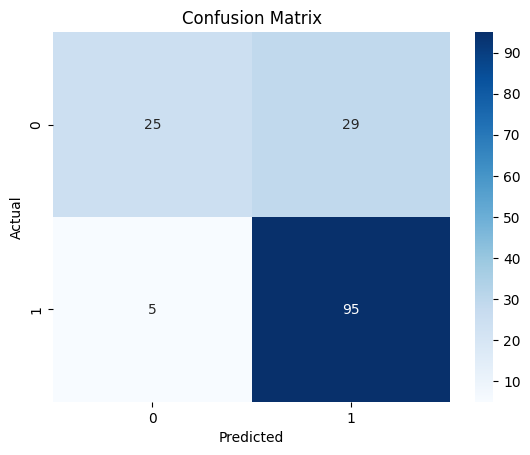

In [103]:
cm = confusion_matrix(y_test,y_pred4)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [104]:
result = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred1),
        accuracy_score(y_test,y_pred2),
        accuracy_score(y_test,y_pred3),
        accuracy_score(y_test,y_pred4)
    ]
})
print(result)

                 Model  Accuracy
0  Logistic Regression  0.772727
1                  KNN  0.759740
2        Decision Tree  0.694805
3        Random Forest  0.779221


In [105]:
best = result.loc[result['Accuracy'].idxmax()]
print("Best Model:", best["Model"])
print("Accuracy:", best["Accuracy"])

Best Model: Random Forest
Accuracy: 0.7792207792207793


Model Comparison

/tmp/ipykernel_792/241473013.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


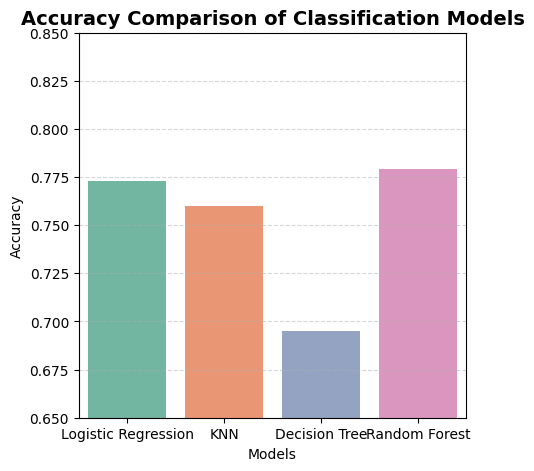

In [106]:
plt.figure(figsize=(5, 5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=result,
    palette="Set2"
)

plt.title("Accuracy Comparison of Classification Models",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.ylim(0.65, 0.85)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

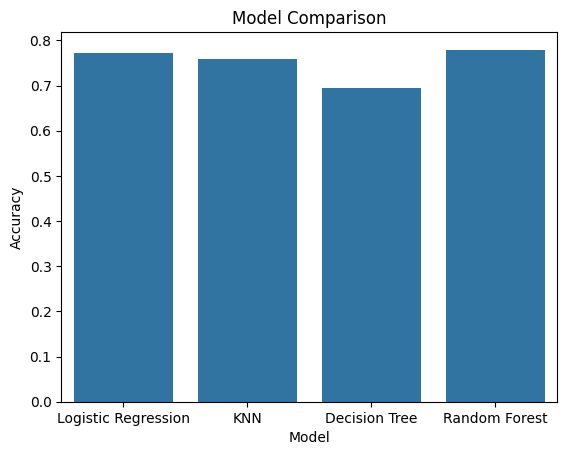

In [107]:
sns.barplot(x="Model", y="Accuracy", data=result)

plt.title("Model Comparison")
plt.show()